# 02 · Estadísticos del corpus
**Proyecto:** Marco COM-B en la esfera pública — análisis de tweets en español  
**Equivalente original:** `3_estadisticos_corpus.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper (columnas de opinión) | Este notebook (tweets) |
|---|---|---|
| Unidad de análisis | Columna de opinión (~600 palabras) | Tweet (~25 palabras) |
| Distribución de párrafos | Sí (textos largos tienen párrafos) | No aplica |
| Agrupación por medio | Diario (El Espectador, El Tiempo, Semana) | Tipo de cuenta (`Entidad`) |
| Agrupación por autor | Autor del columnista | `Author_Normalized` |
| Nube de palabras | Con máscara gaussiana | Rectangular estándar |

**Entradas:**
- `resultadosCOMB/corpus_cleaned.parquet`

**Salidas:**
- `resultadosCOMB/estadisticos_corpus.xlsx`
- `resultadosCOMB/nube_corpus.png`


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

# Columnas (igual que en notebook 01)
COL_AUTOR       = 'Author_Normalized'
COL_AUTOR_NAME  = 'Author Name'
COL_FECHA       = 'Fecha'
COL_ENTIDAD     = 'Entidad'       # tipo de cuenta: reemplaza 'Diario' del paper
COL_SENTIMIENTO = 'Sentimiento'
COL_POLARIDAD   = 'Polaridad'
COL_LIKES       = 'Number of Likes'
COL_RTS         = 'Number of Retweets'

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB


## 1 · Carga de datos
En el paper: `corpus = pd.read_excel(..., 'corpus_cleaned.xlsx')`  
Aquí leemos el parquet generado en el notebook 01.


In [2]:
# ============================================================
# CELL 1 — CARGA
# Equivalente a: corpus = pd.read_excel('corpus_cleaned.xlsx')
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import spacy
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus[COL_FECHA] = pd.to_datetime(corpus[COL_FECHA], errors='coerce')

print(f'Tweets cargados : {len(corpus):,}')
print(f'Columnas        : {list(corpus.columns)}')
corpus.head(3)


Tweets cargados : 151,424
Columnas        : ['id_doc', 'Author_Normalized', 'Author Name', 'Fecha', 'Date', 'anio', 'mes', 'anio_mes', 'Location', 'Number of Likes', 'Number of Retweets', 'Hashtags', 'Mentions', 'Sentimiento', 'Polaridad', 'Entidad', 'Content', 'Texto_limpio', 'n_palabras']


,id_doc,Author_Normalized,Author Name,Fecha,Date,anio,mes,anio_mes,Location,Number of Likes,Number of Retweets,Hashtags,Mentions,Sentimiento,Polaridad,Entidad,Content,Texto_limpio,n_palabras
0,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,['#panama'],[],otro,Neutra,"Noticias locales, nacionales o globales",VÍDEO| Reos que no están contagiados con COVID...,VDEO Reos que no están contagiados con COVID19...,15
1,2,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,[],"['@ivanduque', '@jaimepumarejo']",otro,Negativa,Sin descripción,@IvanDuque @jaimepumarejo ya se enteraron de l...,ya se enteraron de la muerte supestamente por ...,24
2,3,@ferumapress,Fernando Umaña Mejía,2020-06-03,2020-06-03 18:56:17,2020,6,2020-06,NaN,0.0,0.0,[],"['@eltiempo', '@eltiempocali']",otro,Negativa,"Noticias locales, nacionales o globales",El calvario de una familia en Cali por su mamá...,El calvario de una familia en Cali por su mamá...,14


## 2 · Inspección general

In [3]:
# ============================================================
# CELL 2 — INFO
# Equivalente a: corpus.info()
# ============================================================
corpus.info()


<class 'pandas.DataFrame'>
RangeIndex: 151424 entries, 0 to 151423
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_doc              151424 non-null  int64         
 1   Author_Normalized   151424 non-null  str           
 2   Author Name         151384 non-null  str           
 3   Fecha               151424 non-null  datetime64[us]
 4   Date                151424 non-null  datetime64[us]
 5   anio                151424 non-null  int32         
 6   mes                 151424 non-null  int32         
 7   anio_mes            151424 non-null  str           
 8   Location            4532 non-null    str           
 9   Number of Likes     151424 non-null  float64       
 10  Number of Retweets  151424 non-null  float64       
 11  Hashtags            151424 non-null  str           
 12  Mentions            151424 non-null  str           
 13  Sentimiento         151424 non-null  str

## 3 · Estadísticos básicos
En el paper la unidad es la columna de opinión (~600 palabras).  
Aquí la unidad es el tweet (~25 palabras). Las métricas son las mismas.

In [4]:
# ============================================================
# CELL 3 — ESTADÍSTICOS BÁSICOS
# Equivalente a la tabla stats_basicas del paper,
# con métricas adaptadas a tweets.
# ============================================================

# n_palabras ya viene del notebook 01; recalculamos por si acaso
corpus['n_palabras'] = corpus['Texto_limpio'].str.split().str.len()

stats = {
    'Total tweets'                : len(corpus),
    'Total palabras'              : int(corpus['n_palabras'].sum()),
    'Promedio palabras/tweet'     : round(corpus['n_palabras'].mean(), 1),
    'Mediana palabras/tweet'      : corpus['n_palabras'].median(),
    'Maximo palabras/tweet'       : corpus['n_palabras'].max(),
    'Minimo palabras/tweet'       : corpus['n_palabras'].min(),
    'Autores distintos'           : corpus[COL_AUTOR].nunique(),
    'Tipos de cuenta (Entidad)'   : corpus[COL_ENTIDAD].nunique(),
}

tabla_stats = pd.DataFrame(stats.items(), columns=['Estadistico', 'Valor'])
print(tabla_stats.to_string(index=False))
tabla_stats


              Estadistico     Valor
             Total tweets  151424.0
           Total palabras 4431049.0
  Promedio palabras/tweet      29.3
   Mediana palabras/tweet      30.0
    Maximo palabras/tweet      63.0
    Minimo palabras/tweet       5.0
        Autores distintos   79938.0
Tipos de cuenta (Entidad)       8.0


,Estadistico,Valor
0,Total tweets,151424.0
1,Total palabras,4431049.0
2,Promedio palabras/tweet,29.3
3,Mediana palabras/tweet,30.0
4,Maximo palabras/tweet,63.0
5,Minimo palabras/tweet,5.0
6,Autores distintos,79938.0
7,Tipos de cuenta (Entidad),8.0


## 4 · Distribución de longitud de tweets
En el paper esta gráfica muestra columnas de opinión con distribución  
concentrada en ~500-700 palabras. En tweets esperamos un pico en ~15-30 palabras.

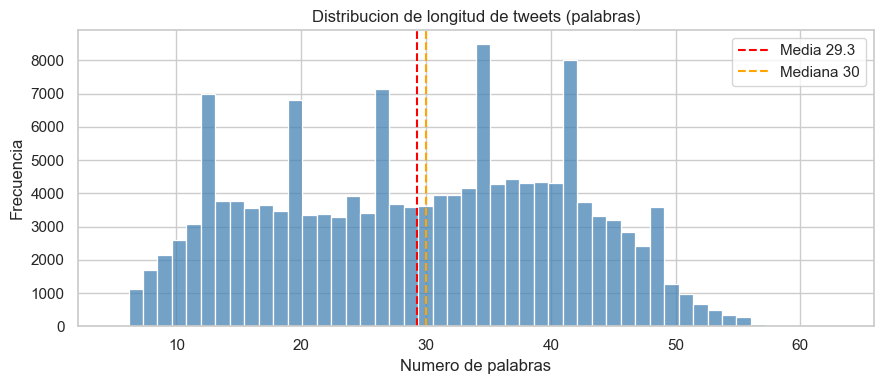

In [5]:
# ============================================================
# CELL 4 — HISTOGRAMA DE LONGITUD
# Equivalente a: sns.histplot(corpus['n_palabras'], bins=50)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(corpus['n_palabras'], bins=50, color='steelblue', ax=ax)
ax.axvline(corpus['n_palabras'].mean(),   color='red',    linestyle='--',
           label=f"Media {corpus['n_palabras'].mean():.1f}")
ax.axvline(corpus['n_palabras'].median(), color='orange', linestyle='--',
           label=f"Mediana {corpus['n_palabras'].median():.0f}")
ax.set_title('Distribucion de longitud de tweets (palabras)')
ax.set_xlabel('Numero de palabras')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_distribucion_longitud.png', dpi=150)
plt.show()


## 5 · Distribución temporal
En el paper: número de columnas publicadas por mes.  
Aquí: número de tweets por mes.

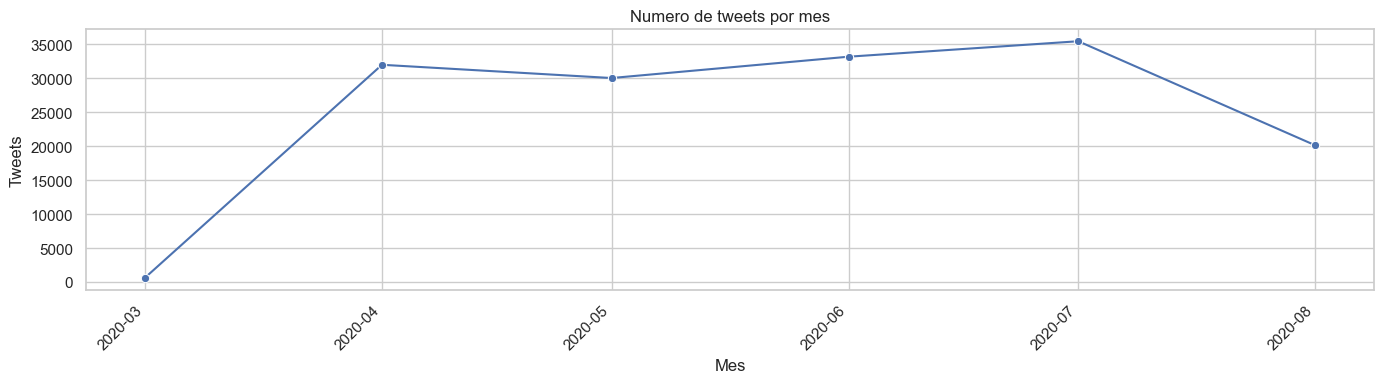

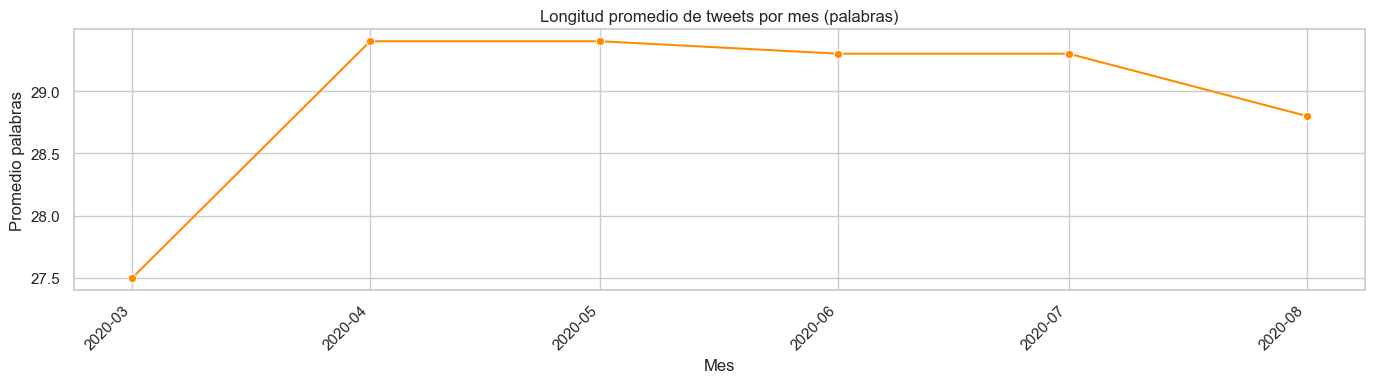

,n_tweets,prom_palabras,n_autores
0,593,27.5,557
1,32000,29.4,22873
2,30048,29.4,20938
3,33193,29.3,22127
4,35469,29.3,22706


In [6]:
# ============================================================
# CELL 5 — DISTRIBUCION TEMPORAL
# Equivalente a: tabla_por_mes con n_columnas y prom_palabras
# ============================================================

tabla_por_mes = (
    corpus.groupby(corpus[COL_FECHA].dt.to_period('M'))
    .agg(
        n_tweets     = ('id_doc',      'count'),
        prom_palabras= ('n_palabras',  'mean'),
        n_autores    = (COL_AUTOR,     'nunique'),
    )
    .reset_index()
)
tabla_por_mes['Fecha'] = tabla_por_mes[COL_FECHA].dt.to_timestamp()
tabla_por_mes['prom_palabras'] = tabla_por_mes['prom_palabras'].round(1)

# -- Grafica 1: volumen mensual --
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=tabla_por_mes, x='Fecha', y='n_tweets', marker='o', ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')
ax.set_title('Numero de tweets por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Tweets')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_tweets_por_mes.png', dpi=150)
plt.show()

# -- Grafica 2: longitud promedio por mes --
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=tabla_por_mes, x='Fecha', y='prom_palabras',
             marker='o', color='darkorange', ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')
ax.set_title('Longitud promedio de tweets por mes (palabras)')
ax.set_xlabel('Mes')
ax.set_ylabel('Promedio palabras')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_longitud_promedio_mes.png', dpi=150)
plt.show()

tabla_por_mes.drop(columns=[COL_FECHA]).head()


## 6 · Distribución por tipo de cuenta
En el paper: `tabla_diario_autores` agrupa por periódico (El Espectador, etc.)  
y cuenta columnas + autores distintos.  
Aquí reemplazamos 'Diario' por `Entidad` (tipo de cuenta: Doctor, Noticias, etc.)

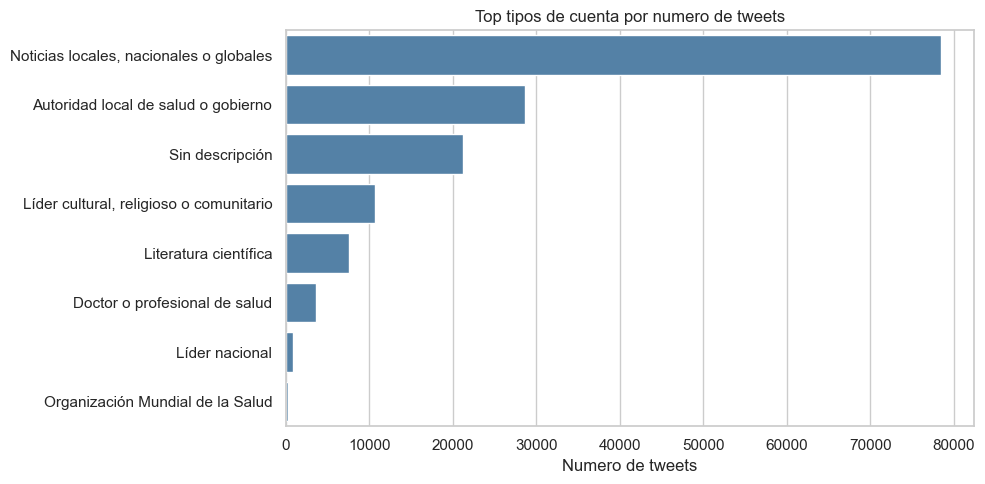

,Entidad,n_tweets,n_autores,pct_tweets
5,"Noticias locales, nacionales o globales",78475,34205,51.82
0,Autoridad local de salud o gobierno,28684,17092,18.94
7,Sin descripción,21195,15332,14.00
3,"Líder cultural, religioso o comunitario",10705,7007,7.07
2,Literatura científica,7554,4657,4.99
1,Doctor o profesional de salud,3677,1981,2.43
4,Líder nacional,874,422,0.58
6,Organización Mundial de la Salud,260,116,0.17


In [7]:
# ============================================================
# CELL 6 — DISTRIBUCION POR TIPO DE CUENTA
# Equivalente a: tabla_diario_autores (paper usa Diario; nosotros usamos Entidad)
# ============================================================

tabla_entidad = (
    corpus.groupby(COL_ENTIDAD)
    .agg(
        n_tweets  = ('id_doc',   'count'),
        n_autores = (COL_AUTOR,  'nunique'),
    )
    .reset_index()
    .sort_values('n_tweets', ascending=False)
)
tabla_entidad['pct_tweets'] = (tabla_entidad['n_tweets'] / len(corpus) * 100).round(2)

# Grafica
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=tabla_entidad.head(15),
    y=COL_ENTIDAD, x='n_tweets',
    color='steelblue', ax=ax
)
ax.set_title('Top tipos de cuenta por numero de tweets')
ax.set_xlabel('Numero de tweets')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_tweets_por_entidad.png', dpi=150)
plt.show()

tabla_entidad


## 7 · Top autores por volumen de tweets
Equivalente a la distribución por autor del paper.

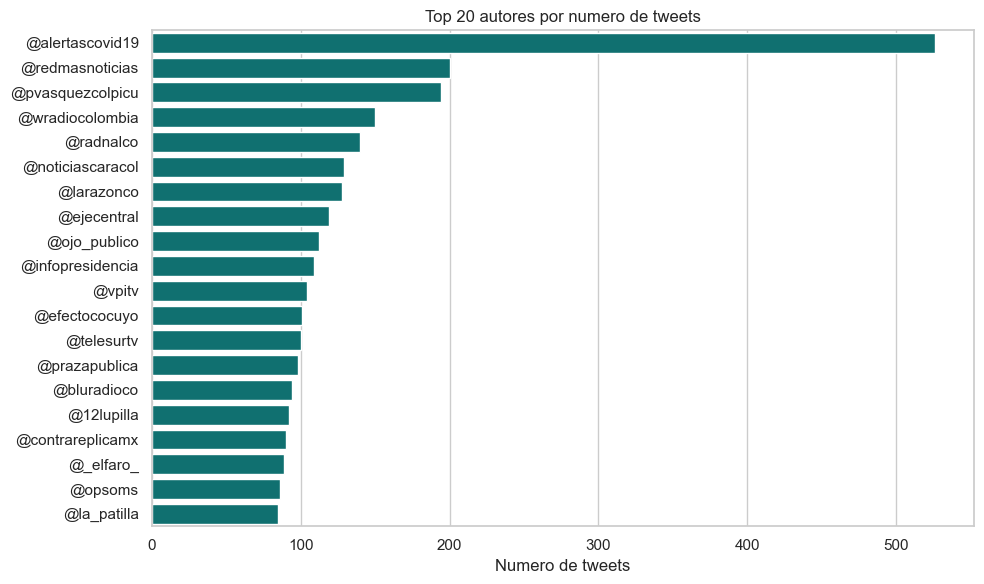

,Author_Normalized,n_tweets
3837,@alertascovid19,526
65822,@redmasnoticias,200
64039,@pvasquezcolpicu,194
78485,@wradiocolombia,150
64692,@radnalco,140
57882,@noticiascaracol,129
45197,@larazonco,128
23366,@ejecentral,119
58638,@ojo_publico,112
35545,@infopresidencia,109


In [8]:
# ============================================================
# CELL 7 — TOP AUTORES
# ============================================================

top_autores = (
    corpus.groupby(COL_AUTOR)
    .agg(n_tweets=('id_doc', 'count'))
    .reset_index()
    .sort_values('n_tweets', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_autores,
    y=COL_AUTOR, x='n_tweets',
    color='teal', ax=ax
)
ax.set_title('Top 20 autores por numero de tweets')
ax.set_xlabel('Numero de tweets')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_autores.png', dpi=150)
plt.show()

top_autores


## 8 · Distribución de sentimiento y polaridad
Análisis adicional propio del corpus de Twitter —  
no existe en el paper porque las columnas de opinión no tienen estas etiquetas.

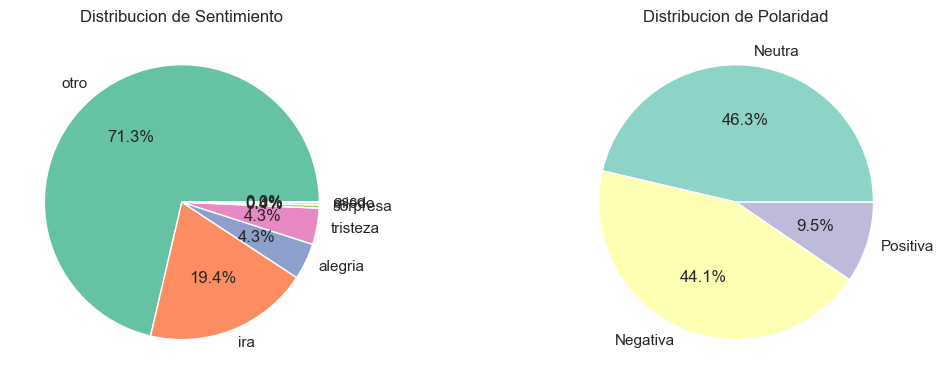

Sentimiento:
Sentimiento
otro        108039
ira          29384
alegria       6488
tristeza      6463
sorpresa       571
miedo          426
asco            53

Polaridad:
Polaridad
Neutra      70160
Negativa    66834
Positiva    14430


In [9]:
# ============================================================
# CELL 8 — SENTIMIENTO Y POLARIDAD
# Analisis adicional exclusivo del corpus de Twitter
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sentimiento
sent_counts = corpus[COL_SENTIMIENTO].value_counts()
axes[0].pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(sent_counts))
)
axes[0].set_title('Distribucion de Sentimiento')

# Polaridad
pol_counts = corpus[COL_POLARIDAD].value_counts()
axes[1].pie(
    pol_counts.values,
    labels=pol_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3', len(pol_counts))
)
axes[1].set_title('Distribucion de Polaridad')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_sentimiento_polaridad.png', dpi=150)
plt.show()

print('Sentimiento:')
print(sent_counts.to_string())
print()
print('Polaridad:')
print(pol_counts.to_string())


## 9 · Riqueza léxica
Vocabulario total, palabras únicas por tweet y TTR (Type-Token Ratio).  
Mismas métricas que el paper.

In [10]:
# ============================================================
# CELL 9 — RIQUEZA LEXICA
# Equivalente a la tabla tabla_lexico del paper
# ============================================================

tokens = ' '.join(corpus['Texto_limpio'].dropna()).split()
vocabulario = set(tokens)
ttr = len(vocabulario) / len(tokens)

tabla_lexico = pd.DataFrame({
    'Metrica': [
        'Total tokens',
        'Palabras unicas (vocabulario)',
        'Promedio palabras unicas / tweet',
        'TTR (Type-Token Ratio)',
    ],
    'Valor': [
        len(tokens),
        len(vocabulario),
        round(corpus['Texto_limpio'].apply(lambda x: len(set(str(x).split()))).mean(), 1),
        round(ttr, 4),
    ]
})

print(tabla_lexico.to_string(index=False))
tabla_lexico


                         Metrica       Valor
                    Total tokens 4431049.000
   Palabras unicas (vocabulario)  274768.000
Promedio palabras unicas / tweet      25.800
          TTR (Type-Token Ratio)       0.062


,Metrica,Valor
0,Total tokens,4431049.000
1,Palabras unicas (vocabulario),274768.000
2,Promedio palabras unicas / tweet,25.800
3,TTR (Type-Token Ratio),0.062


## 10 · Nube de palabras del corpus
En el paper se usa una máscara gaussiana para darle forma de nube.  
Mantenemos esa misma técnica.

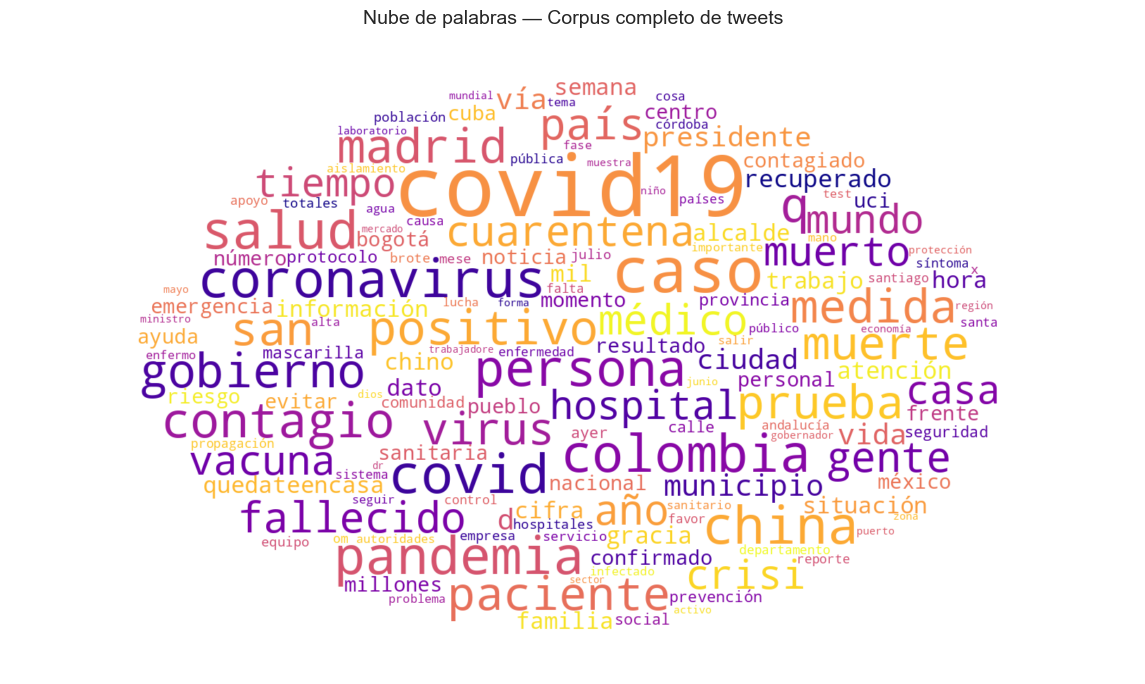

[GUARDADO] nube_corpus.png


In [11]:
# ============================================================
# CELL 10 — NUBE DE PALABRAS
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'es_core_news_sm'],
               capture_output=True)

nlp = spacy.load('es_core_news_sm')
STOP_WORDS = nlp.Defaults.stop_words

texto_total = ' '.join(corpus['Texto_limpio'].dropna()).lower()

# -- Máscara gaussiana (igual que en el paper) --
width, height = 1600, 900
x, y = np.meshgrid(
    np.linspace(-1.5, 1.5, width),
    np.linspace(-1.0, 1.0, height)
)
sigma_x, sigma_y = 0.6, 0.45
gaussian_mask = np.exp(-(x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2)))
mask = (gaussian_mask > 0.15).astype(np.uint8) * 255

wordcloud = WordCloud(
    width=width, height=height,
    background_color='white',
    mask=255 - mask,
    max_words=150,
    stopwords=STOP_WORDS,
    collocations=False,
    prefer_horizontal=1.0,
    relative_scaling=0.3,   # <-- clave: suaviza diferencias de frecuencia
    max_font_size=120,       # <-- techo de tamaño
    min_font_size=8,         # <-- palabras pequeñas más legibles
    random_state=42,
    colormap='plasma',
).generate(texto_total)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras — Corpus completo de tweets', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_corpus.png', dpi=300)
plt.show()
print('[GUARDADO] nube_corpus.png')


## 11 · Guardar tablas de resultados

In [12]:
# ============================================================
# CELL 11 — GUARDAR TABLAS
# Todos los resultados tabulares en un solo Excel multi-hoja
# ============================================================

ruta_excel = DATA_PROCESSED / 'estadisticos_corpus.xlsx'

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    tabla_stats.to_excel(writer,      sheet_name='Resumen_general',   index=False)
    tabla_por_mes.rename(
        columns={'Fecha': 'fecha_mes'}).to_excel(writer,                
                                                 sheet_name='Por_mes',           
                                                 index=False)
    tabla_entidad.to_excel(writer,    sheet_name='Por_tipo_cuenta',   index=False)
    top_autores.to_excel(writer,      sheet_name='Top_autores',       index=False)
    tabla_lexico.to_excel(writer,     sheet_name='Riqueza_lexica',    index=False)

print(f'[GUARDADO] estadisticos_corpus.xlsx -> {ruta_excel}')
print()
print('Notebook 02 completado.')
print('Siguiente -> 03_embeddings_similitudes.ipynb')


[GUARDADO] estadisticos_corpus.xlsx -> C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB\estadisticos_corpus.xlsx

Notebook 02 completado.
Siguiente -> 03_embeddings_similitudes.ipynb
